### Notebook 02: Data Preparation & Modeling
Metadatos:
Autor: Eric Acosta
19/04/2026
Version 1.0

**Agentic Retention Platform (ARP)**
**Project Context**
Following the CRISP-DM framework, we have completed the Data Understanding (Phase 2). We are now entering Data Preparation (Phase 3) and Modeling (Phase 4). Our goal is to transform raw telemetry into a high-performance feature set for an XGBoost model, which will then serve as the "brain" for our Agentic Retention Platform.

**Phase 2 Findings: The Blueprint (Source of Truth)**
**Note:** These findings were extracted from the initial audit and guide our current pipeline.
Target = 'Churn Label'

**1. Data Purge: The "Dead Weight" & Leakage Control**
**Cardinality = 1:** Remove Quarter, Country, State.
**Identifiers:** Drop Customer ID from training (retain as metadata).
**Geographic Noise:** Zip Code is redundant.
**Data Leakage:** Remove Customer Status, Churn Score, Churn Category, and Churn Reason.
**Financial Redundancy:** Drop Total Revenue; prioritize Total Charges.

**2. Logic & Consistency: The "Guardrails"**
**Binary Target:** Map Churn Label to 1 (Yes) and 0 (No).
**The Ghost Filter:** Exclude Tenure == 0 for training (to be managed separately by the Platform).
**Service Dependency:** If Internet Service == 'No', then all internet add-ons (Tech Support, etc.) must be 'No internet service'.
**Financial Drift:** Create a flag for records where (Monthly Charges * Tenure) deviates >15% from Total Charges.

**3. Feature Transformation**
**Contextual Imputation:** Offer -> 'No Offer'; Internet Type -> 'No Internet'.
**Encoding:** One-Hot Encoding for low-cardinality categorical variables.

**4. Feature Engineering**
**Price Shock:** Interaction between Contract Type and Monthly Charge.
**Loyalty Curve:** Analyze the full 72-month Tenure.
**Cluster Regions:** Apply K-Means to Latitude and Longitude to create 5 geographic risk zones.

**5. Modeling Strategy**
**Cost-Sensitive Learning:** Use scale_pos_weight in XGBoost to penalize False Negatives (Churners missed).
**The Vault (Surgical Split):** Isolate 10% of RAW data immediately to simulate the Agent's real-world environment.

### PHASE 3 Data preparation
**Output**
**Dataset**
These are the dataset(s) produced by the data preparation phase, used for modeling or for the major
analysis work of the project.

**Output**
**Dataset description**
This is the description of the dataset(s) used for the modeling or for the major analysis work of the project.

**3.1 Select data**
**Task Select data**
Decide on the data to be used for analysis. Criteria include relevance to the data mining goals, quality,
and technical constraints such as limits on data volume or data types.
**Output**
**Rationale for inclusion/exclusion**
List the data to be used/excluded and the reasons for these decisions.
Activities
* Collect appropriate additional data (from different sources—in-house as well as externally)
* Perform significance and correlation tests to decide if fields should be included
* Reconsider Data Selection Criteria (See Task 2.1) in light of experiences of data quality and data
exploration (i.e., may wish include/exclude other sets of data)
* Reconsider Data Selection Criteria (See Task 2.1) in light of experience of modeling (i.e., model
assessment may show that other datasets are needed)
* Select different data subsets (e.g., different attributes, only data which meet certain conditions)
* Consider the use of sampling techniques (e.g., A quick solution may involve splitting test and training
datasets or reducing the size of the test dataset, if the tool cannot handle the full dataset. It may also
be useful to have weighted samples to give different importance to different attributes or different
values of the same attribute.)
* Document the rationale for inclusion/exclusion
* Check available techniques for sampling data
**Good idea!** Based on Data Selection Criteria, decide if one or more attributes are more important than others and weight the attributes accordingly. Decide, based on the context (i.e., application, tool, etc.), how to handle the weighting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
import logging
from typing import Optional, Tuple, Union
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML

# Logger Configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s - %(message)s",
    force=True
)

#Display settings
%matplotlib inline
sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')

In [2]:
# Definition of route and procedural load

def ingest_and_isolate_vault(
    file_path: str,
    vault_output_path: str,
    test_size: float=0.10,
    random_state: int=42
    ) -> Optional[pd.DataFrame]:
    """
    Reads raw data from a compressed CSV, splits it using stratified sampling
    based on 'Churn Label' and securely save the holdout set.
    
    Args:
        file_path (str): Path to the raw ZIP compressed CSV file.
        vault_output_path (str): File path where the holdout set (The Vault) will be saved. 
        test_file (float, optional): Proportion of the dataset to include in the holdout split. Default to 0.10
        random_state (int, optional): Controls the  shuffling applied to the data before splitting.
        
    Returns:
        Optional[pd.DataFrame]: The develoment DataFrame (90%) for processing and cleaning for training.
        Returns None if critical extraction occurs.
        
    Raises:
        FileNotFoundError: If the specified file_path does not exist
        pd.errors.EmptyDataError: If the CSV file is empty.
        KeyError: If 'Churn Label' is missing from the dataset.
    """
    try:
        logging.info(f"Starting ingestion from: {file_path}")
        # 1. Procedural Load
        df_raw = pd.read_csv(file_path, compression='zip')
        
        # 2. Stratified Split
        # We target 'Churn Label' to maintain class balance in both sets
        df_dev, df_vault = train_test_split(
            df_raw,
            test_size=test_size,
            random_state=random_state,
            stratify=df_raw['Churn Label']
        )
        
        # 3. The base directory is created if it does not exist, based on the provided path.
        os.makedirs(os.path.dirname(vault_output_path), exist_ok=True)
        df_vault.to_csv(vault_output_path, index=False)
        
        logging.info(f"The Vault ({(test_size * 100):.0f}%) locked at: {vault_output_path}")
        logging.info(f"Development Set ({(1 - test_size) * 100:.0f}%) ready: {df_dev.shape[0]} rows.")
        
        return df_dev
    
    except (FileNotFoundError, pd.errors.EmptyDataError, KeyError) as e:
        logging.error(f"Data validation error during ingestion: {e}")
        return None

# --- Execution ---
DATA_PATH = "../data/raw/telco.zip"
VAULT_PATH = "../data/processed/holdout_life_simulation.csv"

df_dev = ingest_and_isolate_vault(
    file_path=DATA_PATH,
    vault_output_path=VAULT_PATH
    )
    

2026-04-30 20:51:13,220 INFO - Starting ingestion from: ../data/raw/telco.zip
2026-04-30 20:51:13,474 INFO - The Vault (10%) locked at: ../data/processed/holdout_life_simulation.csv
2026-04-30 20:51:13,474 INFO - Development Set (90%) ready: 6338 rows.


### Structural removal
Drop the columns identified on phase 2(Leakage, Zero-variance, Redundant)
Remove: 'Quarter', 'Country', 'State', 'Zip Code', 'Customer Status', 'Churn Score', 'Churn Category', 'Churn Reason', 'Total Revenue'

In [3]:
def structural_removal(
    columns_to_drop: list,
    df: pd.DataFrame
    ) -> Optional [pd.DataFrame]:
    """
    Removes a specified list of columns from a DataFrame.
    
    Args:
        columns_to_drop (list): List of column names to be dropped.
        df (pd.DataFrame): The input DataFrame.
        
    Returns:
        Optional[pd.DataFrame]: The DataFrame without the specified columns.
                                Returns None if the dropping process fails.
    Raises:
        KeyError: If one or more columns in the list are not found in the DataFrame.
    """
    # Preventing DF None
    if df is None:
        logging.error("Critical: Received a  NoneType object instead of a DataFrame. Pipeline aborted")
        return None
    
    try:
        # Inmutability: Work on a copy
        # Execution
        df_out = df.drop(columns=columns_to_drop)
        
        logging.info(f"Successfully dropped {len(columns_to_drop)} columns: {columns_to_drop}")
        logging.info(f"Quantity of Columns before dropping: {df.shape[1]} and after: {df_out.shape[1]}")
        return df_out
     
    except KeyError as e:
        logging.error(f"Failed to drop Columns. Column not found {e}")
        return None
    except Exception as e:
        logging.error(f"Unexpected error during structural removal: {e}")
        return None


# --- Execution ---
cols_to_drop = ['Quarter', 'Country', 'State', 'Zip Code', 'Customer Status', 'Churn Score', 'Churn Category', 'Churn Reason', 'Total Revenue']

df_dev = structural_removal(cols_to_drop, df_dev)


    

2026-04-30 20:51:13,504 INFO - Successfully dropped 9 columns: ['Quarter', 'Country', 'State', 'Zip Code', 'Customer Status', 'Churn Score', 'Churn Category', 'Churn Reason', 'Total Revenue']
2026-04-30 20:51:13,504 INFO - Quantity of Columns before dropping: 50 and after: 41


### Metadata Standardization (Column Naming)
Working with inconsistent column names is a nightmare that causes constant KeyErrors.
**The Action:** Convert all column names to lowercase, replace spaces with underscores (_), and remove special characters (parentheses, percentages, etc.) to enforce snake_case.
**The Risk Avoided:** Prevents syntax errors and ensures your code complies with Python's PEP8 formatting standards.

In [4]:
def standarize_columns(
    df: pd.DataFrame
    ) -> Optional[pd.DataFrame]:
    """
    Standardizes column names to snake_case.
    
    Args:
        df(pd.DataFrame): The input DataFrame
        
    Returns:
        df(pd.DataFrame): The DataFrame with the Standarize Columns
                          Returns None if the cleaning process fails
                          
    Raise:
        Cath all unexpected Memory or Pandas Error
    """
    
    # Defensive Check
    if df is None:
        logging.error(f"Critical: Received NoneType instead of DataFrame")
        return None
    
    try:
        # Inmutability: Work on a copy
        df_out = df.copy()
        
        # Execution()
        df_out.columns = (
            df_out.columns.str.strip().str.lower()
            .str.replace(r'[^\w\s]', '', regex=True)
            .str.replace(r'\s+', '_', regex=True)
        )
        logging.info("Column names succesfully standarized to snake_case")
        return df_out
    
    except Exception as e:
        # Catch-all for unexpected memory or pandas errors
        logging.error(f"Unexpected error during column standarization {e}")
        return None
    
    
# --- Execution ---
df_dev = standarize_columns(df_dev)

2026-04-30 20:51:13,537 INFO - Column names succesfully standarized to snake_case


### Structural String Trimming (Whitespace Removal)
Typing errors in transactional databases are the rule, not the exception. An invisible space at the end of a word makes Pandas treat two identical categories as distinct.
**The Action:** Apply a .strip() to all string (text) columns to remove leading and trailing white spaces.
**The Risk Avoided:** Prevents the model from treating "Madrid" and "Madrid " as two completely different cities.


In [5]:
def trim_string_columns(
    df: pd.DataFrame
) -> Optional[pd.DataFrame]:
    """
    Trims leading and trailing whitespace from all string columns in the DataFrame.
    
    Args:
        df (pd.DataFrame): The input DataFrame.
        
    Returns:
        Optional[pd.DataFrame]: The DataFrame with trimmed string columns.
                                Returns None if the trimming process fails.
    """
    
    # Defensive Check
    if df is None:
        logging.error(f"Critical: Recived NoneType instead of DataFrame. Trimming String Columns aborted")
        return None
    
    try:
        # Inmutability: Work on a copy
        df_out = df.copy()
        
        # Execution
        # Searching for 'object and 'string' types to do not break Math columns
        string_cols = df_out.select_dtypes(include=['object', 'string']).columns
        
        # Exit if no text columns exist
        if len(string_cols) == 0:
            logging.info(f"No string columns found in DataFrame. Trimming skipped.")
            return df_out
        
        # Defensively Strip Spaces
        for col in string_cols:
            # The lambda explicitly checks if 'x' is a string before stripping.
            # This prevent the function from crashing when it hits a true NaN value or a number
            df_out[col] = df_out[col].apply(lambda x: x.strip() if isinstance(x ,str) else x)
            
        # Logging Traceability
        trimmed_columns_list = string_cols.tolist()
        logging.info(f"Successfully trimmed whitespace in {len(trimmed_columns_list)} text columns: {trimmed_columns_list}")
        
        return df_out
    
    except Exception as e:
        # Catch-all for unexpected memory or Pandas errors
        logging.error(f"Unexpected error during string trimming: {e}")
        return None
    

# --- Execution ---
df_dev = trim_string_columns(df_dev)

2026-04-30 20:51:13,602 INFO - Successfully trimmed whitespace in 25 text columns: ['customer_id', 'gender', 'under_30', 'senior_citizen', 'married', 'dependents', 'city', 'referred_a_friend', 'offer', 'phone_service', 'multiple_lines', 'internet_service', 'internet_type', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'churn_label']


### Exposing Hidden Nulls (Ghost Values)
Databases often export the absence of data as text, rather than a true memory null that Pandas can understand.
**The Action:** Search for string representations of missing data like ' ' (empty space), '?', 'N/A', 'null', 'None', or '-' and force their conversion to true system nulls (np.nan).
**The Risk Avoided:** Prevents Pandas from throwing an error when you try to calculate the mean of a numeric column because a '?' slipped into row 4000.

In [6]:
def expose_hidden_nulls(
    df: pd.DataFrame
) -> Optional[pd.DataFrame]:
    """
    Scans string columns for common placeholder values and replaces them with true system nulls (np.nan)

    Args:
        df (pd.DataFrame): The input DataFrame

    Returns:
        Optional[pd.DataFrame]: The DataFrame with exposed nulls.
                                Return None if the Process fails.
    """
    
    if df is None:
        logging.error("Critical: Recived NoneType instead of DataFrame. Aborted")
        return None
    
    try:
        # Inmutability: Work on a copy
        df_out = df.copy()
        
        # Define the Blacklist
        # We include  '' becasue previous trimming function turned '  ' into ''
        blacklist = ['?', '-', 'N/A', 'n/a', 'NA', 'null', 'Null', 'NONE', 'None','', 'np', 'Np', 'n/p']
        
        # Isolate string columns
        string_cols = df_out.select_dtypes(include=['object', 'string']).columns
        
        if len(string_cols) == 0:
            logging.info("No string columns found. Procedure skipped")
            return df_out
        
        # Execution: Replace exact matches with np.nan
        # We use replace() and specify that it must be an exact match to avoid
        # Accidentally turning a valid city like "Nanaimo" into a null just because it has "na"
        df_out[string_cols] = df_out[string_cols].replace(blacklist, np.nan)
        
        logging.info(f"Succesfully exposed hidden nulls across {len(string_cols)} text columns.")
        
        return df_out
    
    except Exception as e:
        logging.error(f"Unexpected error during hidden null exposure: {e}")
        return None
    
# --- Execution ---
df_dev = expose_hidden_nulls(df_dev)

2026-04-30 20:51:13,769 INFO - Succesfully exposed hidden nulls across 25 text columns.


## Strict Type Casting
If a pricing column has a single text typo, Pandas will convert the entire numeric column to an object (text) type.
**The Action:** Forcibly convert columns that are numbers into numeric types (pd.to_numeric), text dates into true datetime objects (pd.to_datetime) and assigning the right cathegorical.
**The Risk Avoided:** Prevents your mathematical model from attempting to multiply strings, or failing to extract the "month" feature from a date column.


In [7]:
import pandas as pd
import logging
from typing import Optional

def cast_data_types(
    df: pd.DataFrame,
    numeric_cols: list = None,
    datetime_cols: list = None,
) -> Optional[pd.DataFrame]:
    """
    Forcibly casts specified columns to numeric or datetime types.
    Invalid parsing will be set as NaN (errors='coerce').

    Args:
        df (pd.DataFrame): The input DataFrame.
        numeric_cols (list): List of column names to cast to float/int.
        datetime_cols (list): List of column names to cast to datetime.

    Returns:
        Optional[pd.DataFrame]: The DataFrame with corrected data types.
                                Returns None if the casting process fails.
    """
    
    if df is None:
        logging.error("Critical: Received NoneType instead of DataFrame. Casting aborted.")
        return None
    
    try:
        df_out = df.copy()
        
        # 1. Cast Numeric Columns
        if numeric_cols:
            successfully_cast_num = [] 
            
            for col in numeric_cols:
                # Defensive Check: Only cast if the column actually exists
                if col in df_out.columns:
                    df_out[col] = pd.to_numeric(df_out[col], errors='coerce')
                    successfully_cast_num.append(col)
                    
            if successfully_cast_num:
                logging.info(f"Successfully cast {len(successfully_cast_num)} numeric columns: {successfully_cast_num}")
            else:
                logging.warning("No numeric columns were found to cast.")
                
        # 2. Cast Datetime Columns
        if datetime_cols:
            successfully_cast_date = []
            
            for col in datetime_cols: 
                if col in df_out.columns:
                    df_out[col] = pd.to_datetime(df_out[col], errors='coerce')
                    successfully_cast_date.append(col)
                    
            if successfully_cast_date:
                logging.info(f"Successfully cast {len(successfully_cast_date)} datetime columns: {successfully_cast_date}")
            else:
                logging.warning("No datetime columns were found to cast.")
                
        return df_out
    
    except Exception as e:
        logging.error(f"Unexpected error during type casting: {e}")
        return None


# --- Execution ---
cols_to_numeric = [
    'age', 'population', 'tenure_in_months', 'monthly_charge', 'total_charges',
    'avg_monthly_long_distance_charges', 'total_long_distance_charges',
    'total_extra_data_charges', 'avg_monthly_gb_download',
    'total_refunds', 'number_of_referrals', 'satisfaction_score'
] 
cols_to_datetime = []

df_dev = cast_data_types(df=df_dev, numeric_cols=cols_to_numeric, datetime_cols=cols_to_datetime)

2026-04-30 20:51:13,805 INFO - Successfully cast 12 numeric columns: ['age', 'population', 'tenure_in_months', 'monthly_charge', 'total_charges', 'avg_monthly_long_distance_charges', 'total_long_distance_charges', 'total_extra_data_charges', 'avg_monthly_gb_download', 'total_refunds', 'number_of_referrals', 'satisfaction_score']


### Absolute Deduplication
Rows that are exact clones across all columns usually stem from SQL table join errors (Cartesian products) or glitches in the source system.
**The Action:** Execute df.drop_duplicates() to purge exact copies.
**The Risk Avoided:** Prevents biasing your model by giving double or triple statistical weight to a single customer just because the export system failed.


In [8]:
def drop_duplicate_rows(
    df: pd.DataFrame
) -> Optional[pd.DataFrame]:
    """
    Removes exact duplicate rows from the DataFrame

    Args:
        df (pd.DataFrame): The imput DataFrame.

    Returns:
        Optional[pd.DataFrame]: The DataFrame with duplicate rows removed
                                Returns None if the process fails
    """
    if df is None:
        logging.error("Critical: Received NoneType instead of DataFrame. Pipeline aborted ")
        return None
    
    try:
        
        # Inmutability: Work on a copy
        df_out = df.copy()
        
        # Count rows before
        initial_rows = len(df_out)
        
        # Execution
        df_out = df_out.drop_duplicates()
        
        # Count rows after
        final_rows = len(df_out)
        duplicates_removed = initial_rows - final_rows
        
        if duplicates_removed > 0:
            logging.info(f"Succesfully removed {duplicates_removed} duplicate rows")
        else:
            logging.info("No exact duplicate rows found. Data intact")
            
        return df_out
    
    except Exception as e:
        logging.error(f"Unexpected error during deduplication: {e}")
        return None
    
# --- Execution Testing ---
df_dev = drop_duplicate_rows(df_dev)

2026-04-30 20:51:13,891 INFO - No exact duplicate rows found. Data intact


## Refactor Target

You CANNOT have missing values (NaN) in your target variable. If a row is missing the answer (whether the customer churned or not), that row is completely useless for training. The algorithm learns by looking at the features and comparing them to the truth. If the truth is missing, it learns nothing.

Furthermore, you must never impute (guess/fill in) the target variable. If you fill missing churn values with the most frequent answer (e.g., "No"), you are literally inventing fake reality and training your model on lies.

In [9]:
def prepare_target_variable(
    df: pd.DataFrame,
    target_col: str='churn_label'
) -> Optional[pd.DataFrame]:
    """
    Prepares target variable by dropping NaNs, standardizing text, 
    verifying binary constraints, and mapping to 1/0.

    Args:
        df (pd.Dataframe): The imput DataFrame
        target_col (str, optional): Target. Defaults to 'churn_label'.

    Returns:
        Optional[pd.DataFrame]: Imputed Data Frame with 0 and 1
    """
    if df is None:
        logging.error("Critical: Received NoneType instead of DataFrame")
        return None
    
    if target_col not in df.columns:
        logging.error(f"Critical: Target column '{target_col}' not found in DataFrame")
        return None
    
    try:
        df_out = df.copy()
        
        # Drop rows where target is missing
        initial_rows = len(df_out)
        df_out = df_out.dropna(subset=[target_col])
        if len(df_out) != initial_rows:
            logging.warning(f"Dropped {initial_rows - len(df_out)} rows with missing target values.")
            
        # Standardize text (Forces everything to string for mapping)
        df_out[target_col] = df_out[target_col].astype(str).str.strip().str.lower()
            
        # Fail-Fast Assertion (Unique values check)
        unique_values = df_out[target_col].unique()
        if len(unique_values) != 2:
            raise ValueError(f"CRITICAL: Target must have 2 unique values. Found {len(unique_values)}: {unique_values}")
    
        # Map text to binary
        mapping = {'yes': 1, 'no': 0, 'true': 1, 'false': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0}
        
        # We perform the mapping directly since we forced string type in Step 2
        df_out[target_col] = df_out[target_col].map(mapping)
        
        # Final validation of the mapping
        if df_out[target_col].isnull().any():
            unmapped = df_out[df_out[target_col].isnull()][target_col].unique()
            raise ValueError(f"CRITICAL: Mapping failed. Unknown values detected: {unmapped}")
            
        # Final Cast to Integer
        df_out[target_col] = df_out[target_col].astype(int)
            
        logging.info(f"Target variable '{target_col}' successfully prepared.")
        return df_out

    except Exception as e:
        logging.error(f"Pipeline Halted: Unexpected error preparing target variable: {e}")
        raise
    
# --- Execution ---
df_dev = prepare_target_variable(df_dev)

2026-04-30 20:51:13,933 INFO - Target variable 'churn_label' successfully prepared.


### Train/Text Split

**The objective:** Split the cleaned dataset into Training (80%) and Testing (20%) environments.

**The strategic Risk (Data Leake)** We must split the data *before* running correlation matrices or imputing 'NaN' values. Analizing the full dataset allows the model to memorize the test data, leading to a false 100% accuracy in devolpment and a total failure in production.

**The matematical Safeguard (Stratification):** Churn is an imbalanced. We use 'stratify=y' to force the algorithm to mantein the exact same proportion of churned clients in both Training and Testing sets. Random spliting would skew the result.

In [10]:
def perform_train_test_split(
    df: pd.DataFrame,
    target_col: str = "churn_label",
    test_size: float = 0.20,
    random_seed: int = 42
) -> Optional[Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]]:
    """
    Split the DataFrame into training and testing sets, ensuring stratification based on the target variable to maintain class distribution.

    Args:
        df (pd.DataFrame): The cleaned DataFrame
        target_col (str): The name of the tagert variable to predict. Defaults to "churn_label".
        test_size (float, optional): The proportion of the dataset to include the text split. Defaults to 0.20.
        random_seed (int, optional): Seed for reproducibility. Defaults to 42.

    Returns:
        Optional[Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]]:
        X_train, X_test, y_train, y_test. Returns None if it fails.
    """
    if df is None:
        loggig.error("Critical: Received None type instead of DataFrame.")
        return None
    
    
    try:
        # Split features (X) and target vector (y)
        X = df.drop(columns=[target_col])
        y = df[target_col]
        
        # Split
        # Stratify='y' to guaranty the same 'Churn' proportion in both
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=random_seed,
            stratify=y
        )
        
        logging.info(f"Data split successfully. Train Shape: {X_train.shape[0]} rows. Test shape {X_test.shape[0]} rows.")
        
        return X_train, X_test, y_train, y_test
    
    except Exception as e:
        logging.error(f"Unexpected error during training-test split: {e}")
        return None
    

# --- Execution ---
X_train, X_test, y_train, y_test = perform_train_test_split(df=df_dev, target_col='churn_label')

2026-04-30 20:51:13,962 INFO - Data split successfully. Train Shape: 5070 rows. Test shape 1268 rows.


In [11]:
# Startify verification
print("Proportion in training:\n", y_train.value_counts(normalize=True))
print("\nProportion in test", y_test.value_counts(normalize=True))

Proportion in training:
 churn_label
0    0.734714
1    0.265286
Name: proportion, dtype: float64

Proportion in test churn_label
0    0.734227
1    0.265773
Name: proportion, dtype: float64


### Merging the training DataFrame in one DataFrame
Reunite the data temporarily for the analysis sandbox

In [12]:
def training_merging (
    df_x_training: pd.DataFrame,
    ser_y_training: Union[pd.DataFrame, pd.Series]
) -> Optional[pd.DataFrame]:
    """
    Merge X_training and y_training for analysis

    Args:
        df_x_training (pd.DataFrame): X_training DataFrame
        ser_y_training (pd.Series): y_training DataFrame

    Returns:
        Optional[pd.DataFrame]: Merged DataFrame
    """
    if df_x_training is None or ser_y_training is None:
        logging.error("Critico: X_train or y_train are Nonetype")
        return None
    
    try:
        # Length validation (Fail-Fast)
        if len(df_x_training) != len(ser_y_training):
            raise ValueError(f"Row mismatch: X has {len(df_x_training)}, and has {len(ser_y_training)}")

        df_out = df_x_training.copy()
        
        # Secure allocation by forcing alignment across values
        # This prevents silent failure if the Pandas indices are unsorted
        df_out['churn_label'] = ser_y_training.values if isinstance(ser_y_training, (pd.Series, pd.DataFrame)) else ser_y_training
        
        logging.info("Features and Target Successfully merged for analysis")
        return df_out
    
    except Exception as e:
        logging.error(f"Merging error for training Data: {e}")
        raise

# --- Execution ----
df_training_analysis = training_merging(X_train, y_train)

2026-04-30 20:51:14,011 INFO - Features and Target Successfully merged for analysis


### 

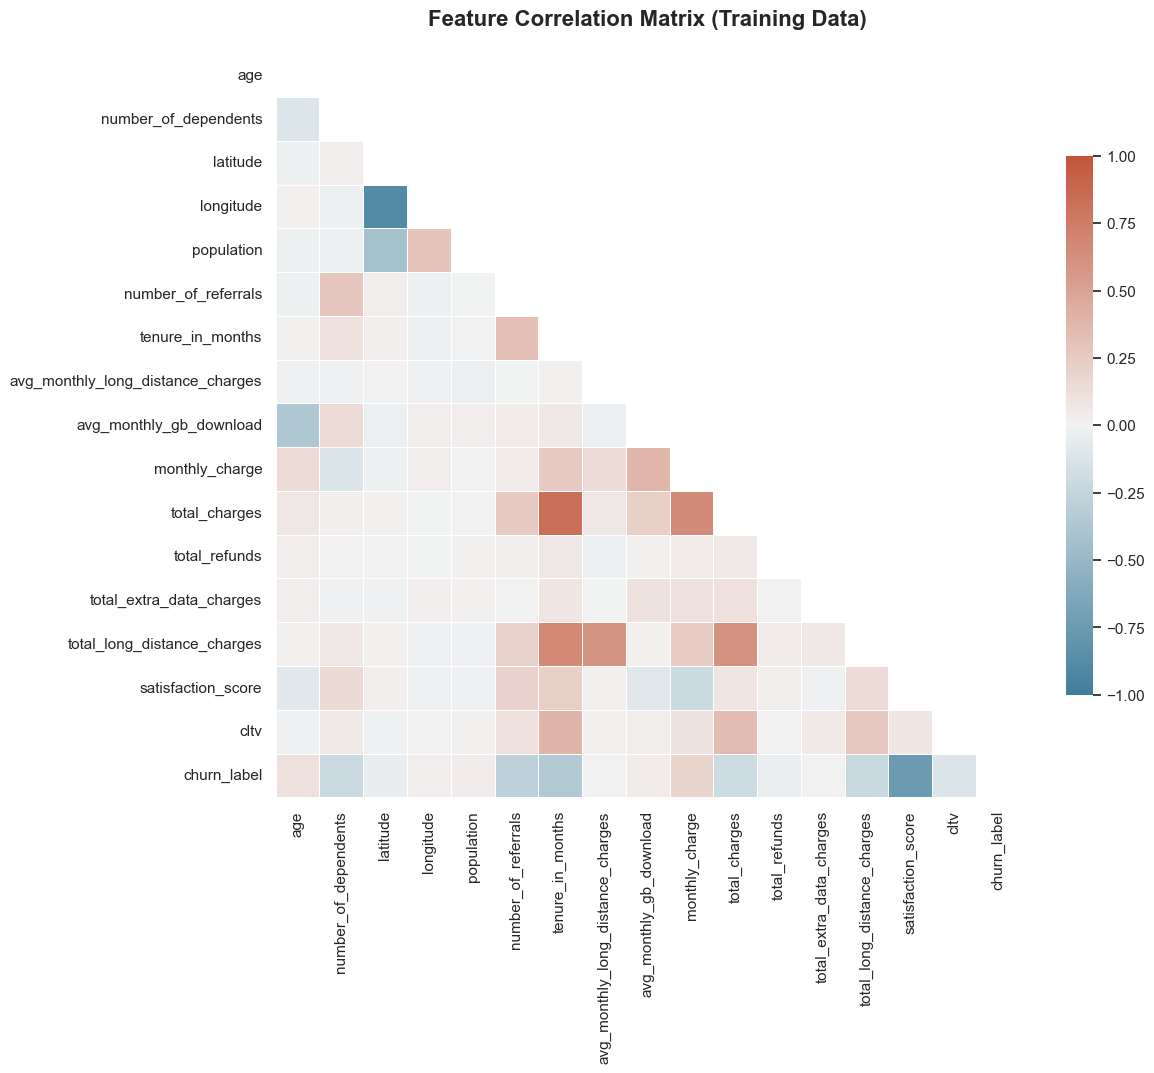


--- The strategic Truth: Impact on Churn ---
churn_label                          1.000000
monthly_charge                       0.191942
age                                  0.115329
avg_monthly_gb_download              0.046752
population                           0.036853
longitude                            0.027974
total_extra_data_charges             0.006788
avg_monthly_long_distance_charges    0.002431
total_refunds                       -0.033157
latitude                            -0.041289
cltv                                -0.124171
total_charges                       -0.196238
number_of_dependents                -0.218295
total_long_distance_charges         -0.219673
number_of_referrals                 -0.283625
tenure_in_months                    -0.348207
satisfaction_score                  -0.755200
Name: churn_label, dtype: float64


In [13]:
### Numerical Correlation Matrix

# Calculate the correlation Matrix
correlation_matrix = df_training_analysis.corr(numeric_only=True)

# Create the mathematical mask for the upper triangle
# This forces the matrix into a modern lower-triangle shape
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the modern matplotlib figure canvas
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

# Generate a diverging colormap (Blue to Red)
# Blue = Negative Correlation (Retention), Red = Positive Correlation (Churn)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap
sns.heatmap(correlation_matrix, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
            annot=True, fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Feature Correlation Matrix (Training Data)', fontsize=16, pad=20, fontweight="bold")
plt.show()

# Print the isolated target correlations so the business logic cannot be ignored
print("\n--- The strategic Truth: Impact on Churn ---")
print(correlation_matrix['churn_label'].sort_values(ascending=False))

### Categorical Bivariate Analysis

2026-04-30 21:42:12,857 INFO - --- Starting Bivariante Analysis for 23


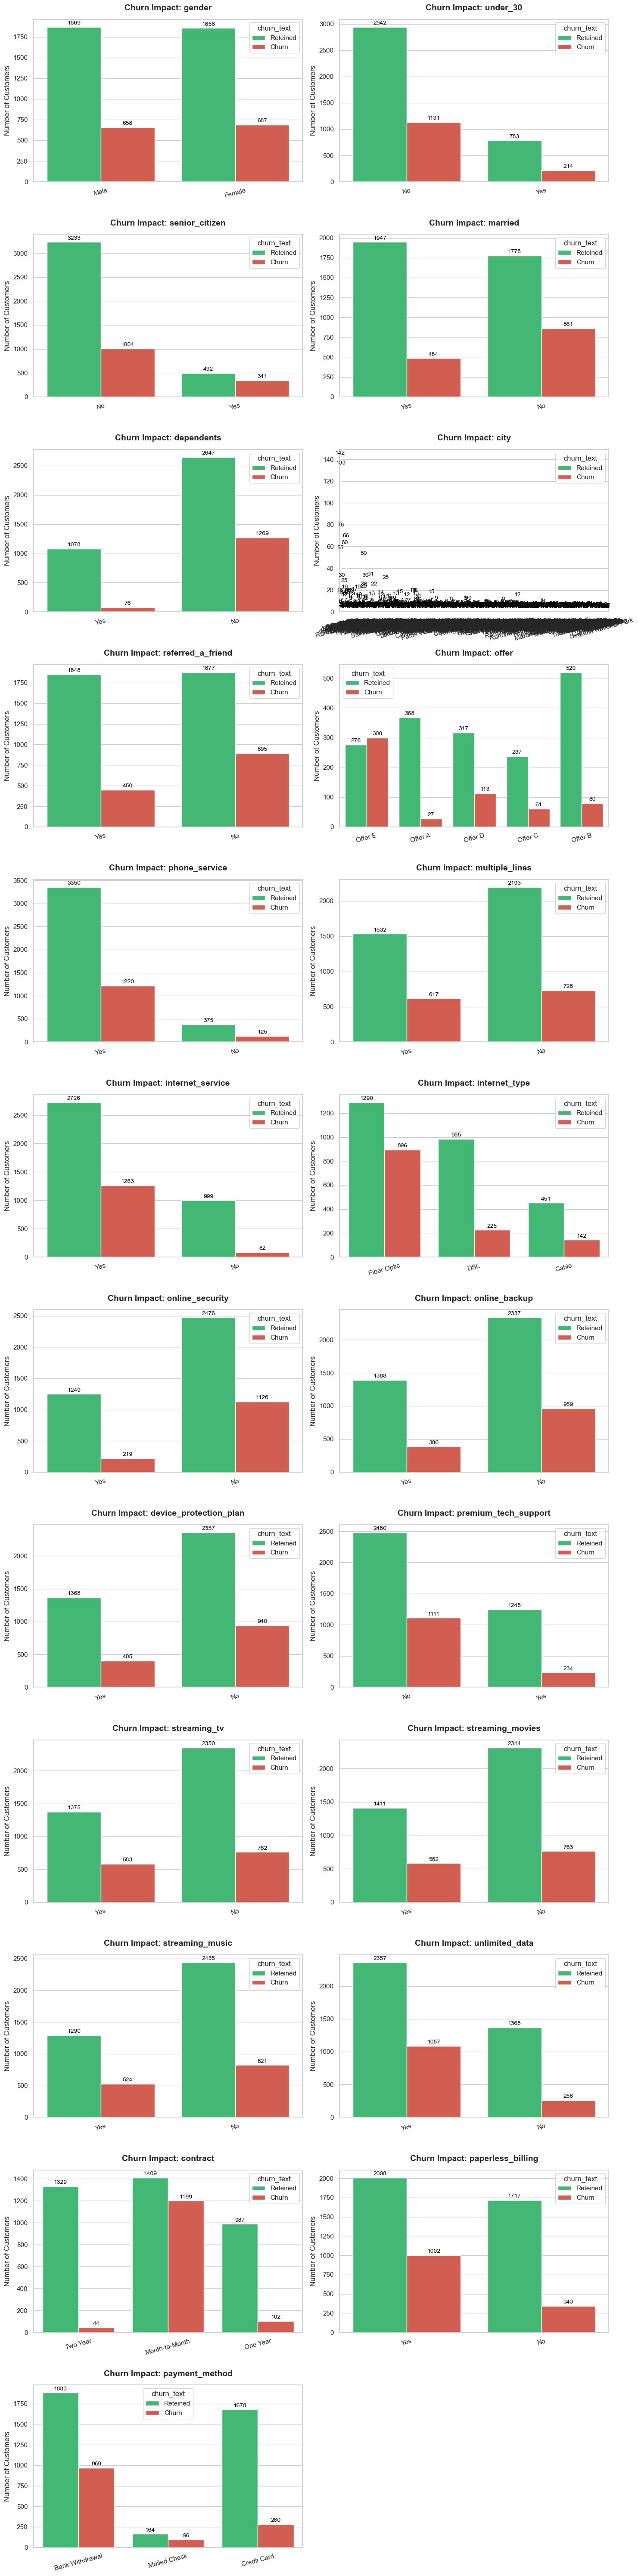

In [21]:
#Automatically identify text (categorical) columns
categorical_cols = df_training_analysis.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

# Create a temporary text column specifically for the chart legend
df_training_analysis['churn_text'] = df_training_analysis['churn_label'].map({1: 'Churn', 0: 'Reteined'})


# Exclude columns that are not useful for bad charts (IDS or the target itself)
cols_to_exclude = ['customer_id', 'churn_label', 'churn_text']
categorical_cols = [col for col in categorical_cols if col not in cols_to_exclude]

logging.info(f"--- Starting Bivariante Analysis for {len(categorical_cols)}")

# Configure the dynamic canvas
# Calculate the necessary rows to place 2 charts per row
n_rows = (len(categorical_cols) + 1) // 2
plt.figure(figsize=(15, 5 * n_rows))
sns.set_theme(style="whitegrid")

# Iterate and plot the relationship with Churn
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, 2, i)
    
    # Count plot divided by Churn (0 and 1)
    # Green = Retained, Red = Churned
    ax = sns.countplot(data=df_training_analysis, x=col, hue='churn_text', palette=['#2ECC71', '#E74C3C'])
    
    plt.title(f'Churn Impact: {col}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=15)
    
    # Add numbers on top of the chart
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Avoid putting 0s on the chart
            ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                        ha="center", va="bottom", fontsize=10, color="black", xytext=(0, 2), textcoords="offset points")
            
plt.tight_layout()
plt.show()